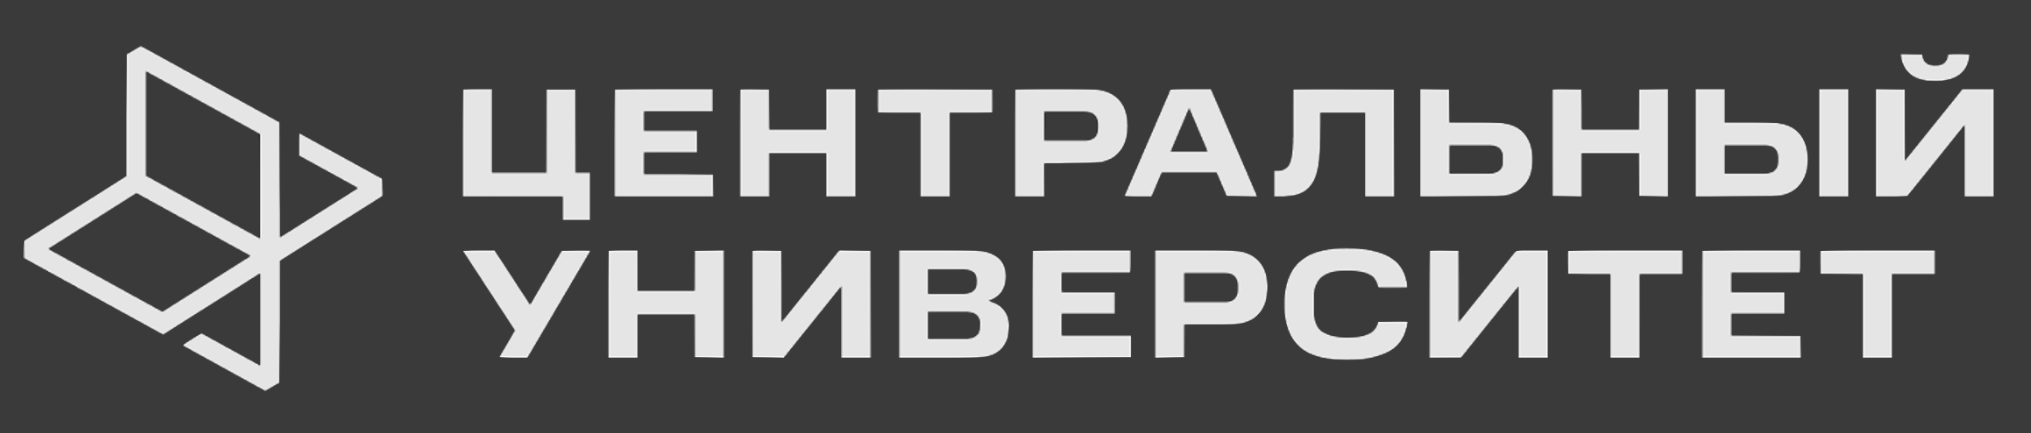

<hr style="border:2px solid gray">

## Домашнее задание 2. Задача детектирования и классификации объектов.


# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличие работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

----
## <font color='OrangeRed'>**Внимание! Алярм! Ахтунг!**</font>

* Данный ноутбук желательно выполнять на внутреней платформе <font color='DarkSeaGreen'>**jupyter.culab**</font> ЦУ.

* Работоспособность данного ноутбука проверена именно на <font color='DarkSeaGreen'>**jupyter.culab**</font>, работоспособность "из-под коробки" на других платформах мы не гарантируем.

* Вы можете делать задание у себя локально/Google Colab/Kaggle и пр. при желании, однако работать с доп файлами и настраивать окружение придется самостоятельно.

* Подробнее о использовании внутренней платформы читайте в описании курса

---
## Формулировка задания

- <font color='DarkOrange'> **[3 баллa]** </font> Воспользоваться материалами семинара разработать модель на основе `ResNet18` архитектуры.
- <font color='DarkOrange'> **[3 балла]** </font>Натренировать модель на основе `ResNet18` архитектуры.
- <font color='DarkOrange'> **[1 балл]** </font>Сравнить скорость работы моделей, основаных на `VGG16` и `ResNet18`.
- <font color='DarkOrange'> **[1 балл]** </font>Сравнить между собой метрики `MAP` для натренированных моделей, основаных на `VGG16` и `ResNet18`.
- <font color='DarkOrange'> **[2 балла]** </font>Визуализация результатов и описание проведенных экспериментов, выводы.

### <font color='MediumSeaGreen'> **Бонусы** </font>
- Применяются для каждой части отдельно
- <font color='MediumSeaGreen'> **[0.5 балла]** </font> Бонус можно получить за визуализацию результатов  в `wandb` - приложите ссылку на отчет о обучении на wandb, подкрепляя это графиками и выводами
- <font color='MediumSeaGreen'> **[до 5 баллов]** </font>Бонус можно получить за попытки реализовать свою архитектуру: например на семинаре мы цепляли пару сверточных слоев, чтобы получить предсказания для поправок `prior_boxes` и `scores` классов, попробуйте реализовать что-то посложнее.
---

<font color='OrangeRed'>**Внимание!**</font> мы тренируем модели на три класса `car, license_plate, background`, поэтому внесите исправления в файле `voc_dataset.py`

<font color='OrangeRed'>**Внимание!**</font> Сохраняйте <font color='OrangeRed'>**все итоговые**</font>, и, лучше, промежуточные результаты обучения и веса и архитуктуры моделей! Данные модели пригодятся вам в дальнейшем при построении целостного проекта!


<font color='OrangeRed'>**Внимание!**</font> SSD на VGG обучается порядка 1 минуты на эпоху, для хорошего результата нужно не менее 20-30 эпох. SSD на ResNet обучается до 0.4 минут на эпоху, для хорошего результата нужно не менее 20-30 эпох

<font color='OrangeRed'>**Внимание!**</font> Вам выдается набор данных с изображениями в разрешении $640{\times}360$ и $1280{\times}720$. Для тренировки модели на `VGG16` используйте $640x360$. Для тренировки модели на `ResNet18` нужно использовать $1280{\times}720$, поскольку регистрационные знаки имеют маленький размер более высокое разрешение позволит из **лучше** детектировать.

<font color='OrangeRed'>**Внимание!**</font> SSD на VGG потребляет большое количество видеопамяти, рекомендуемый batch_size = 3. SSD на ResNet требует существенно меньше память, рекомендуемый batch_size = 6. В случае, если ноутбук падает при таком batch_size, уменьшите его


## Архитектура модели на базе `RESNET18`

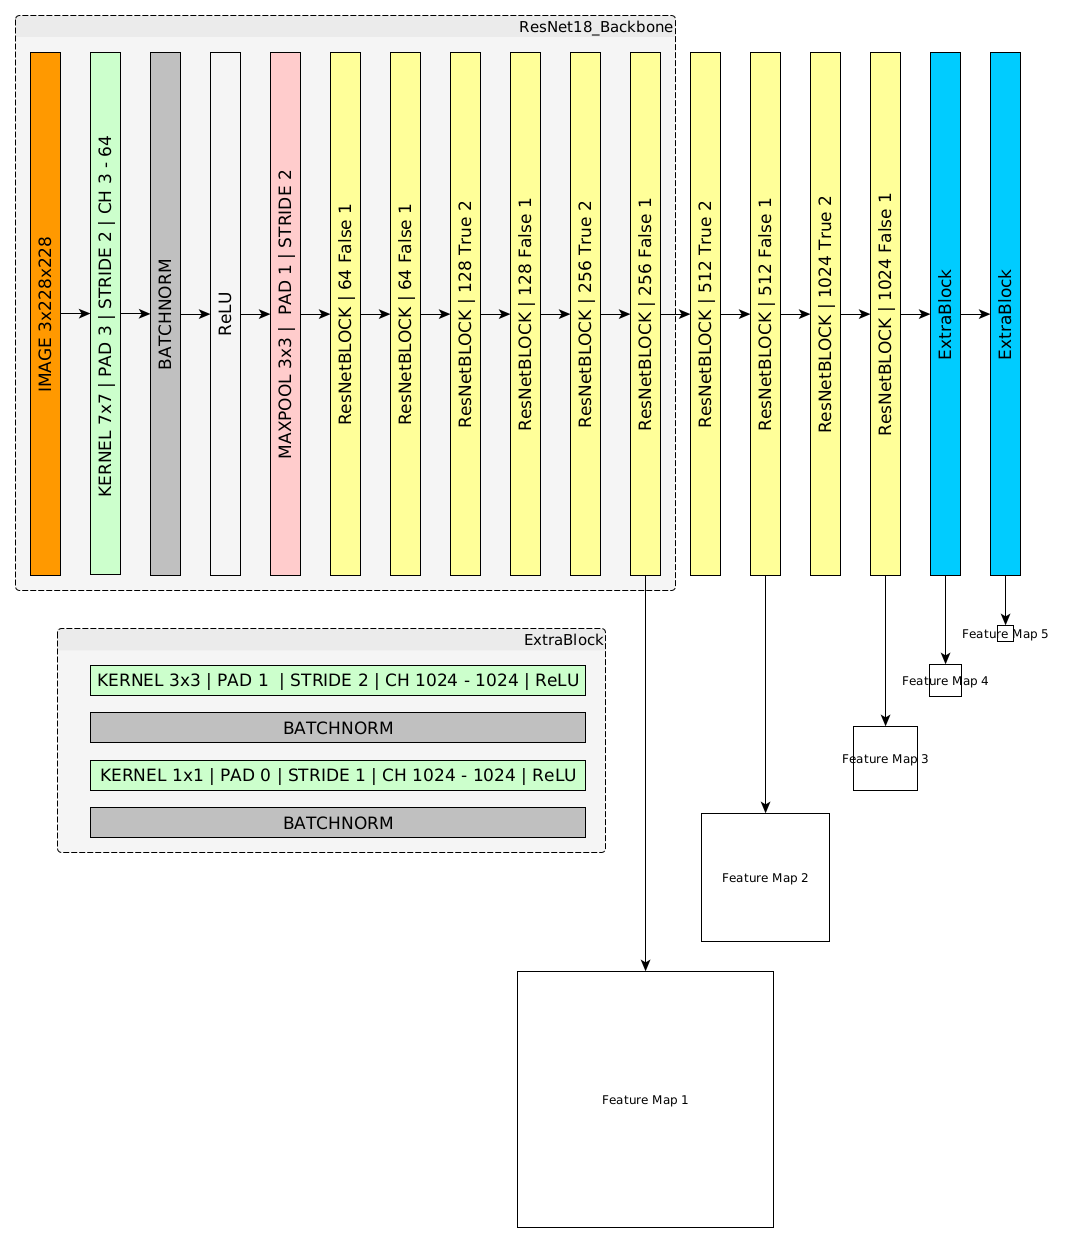

In [1]:
import os
import sys
import time
from pathlib import Path
import warnings


# Убираем все ворнинги
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")


WEEK1 = Path.cwd().resolve()
for root in [WEEK1, *WEEK1.parents]:
    if (root / "dataset" / "ImageSets" / "Main" / "trainval.txt").is_file():
        WEEK1 = root
        break

sys.path.insert(0, str(WEEK1 / "utils"))
os.chdir(WEEK1)

import torch
from torch.optim import Adam, AdamW
from tqdm.auto import tqdm

from voc_dataloader import get_train_dataloader, get_test_dataloader
from voc_dataset import strong_transform, strong_transform_resnet
from multibox_loss import MultiBoxLoss
from compute_map import compute_map, log_eval_map
from prior_boxes import prior_boxes
# from ssd_resnet18 import SSDResNet18, ssd_resnet18_cfg, build_priors
# from ssd_resnet101 import SSDResNet101, ssd_resnet101_cfg, build_priors
from ssd_convnext_t import SSDConvNeXtTiny, ssd_convnext_tiny_cfg, build_priors
from ssd_vgg16 import SSDVGG16, ssd_vgg_cfg

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [2]:
voc_root = str(WEEK1 / "dataset")
train_ann = os.path.join(voc_root, "ImageSets/Main/trainval.txt")
test_ann = os.path.join(voc_root, "ImageSets/Main/test.txt")

BATCH_SIZE = 12
NUM_WORKERS = 4
EPOCHS = 25
EVAL_EVERY = 5

OVERLAP = 0.5
SCORE = 0.01


ckpt_dir = WEEK1 / "checkpoints"
ckpt_dir.mkdir(exist_ok=True)


train_loader = get_train_dataloader(
    voc_root, train_ann, BATCH_SIZE, NUM_WORKERS, sample_transform=strong_transform_resnet
)
test_loader = get_test_dataloader(
    voc_root, test_ann, BATCH_SIZE, NUM_WORKERS, sample_transform=strong_transform_resnet
)

cfg = ssd_convnext_tiny_cfg()
ckpt_resume = ckpt_dir / "ssd_convnextt.pt"
_resume = False #ckpt_resume.is_file()
model = SSDConvNeXtTiny(
    num_classes=cfg["num_classes"],
    pretrained_backbone=not _resume,
).to(DEVICE)

if _resume:
    try:
        pack = torch.load(ckpt_resume, map_location=DEVICE, weights_only=False)
    except TypeError:
        pack = torch.load(ckpt_resume, map_location=DEVICE)
    model.load_state_dict(pack["model"])
    print("loaded", ckpt_resume, "ckpt_epoch=", pack.get("epoch"))
else:
    print("no checkpoint — старт с весов ImageNet")

priors = build_priors(cfg, device=DEVICE)

criterion = MultiBoxLoss(overlap_threshold=OVERLAP, neg_pos_ratio=3, variance=[0.1, 0.2])

for param in model.features[:5]:
    param.requires_grad = False

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4, fused=True)



model = torch.compile(model, mode="reduce-overhead")
model.train()
for epoch in range(EPOCHS):
    ep_loss = 0.0
    loss_c_sum = 0.0
    loss_l_sum = 0.0
    n_batches = 0
    pbar = tqdm(train_loader, desc=f"ResNet18 epoch {epoch + 1}/{EPOCHS}")


    for step, batch in enumerate(pbar):
        images, box_ss, label_ss = batch
    
        if images.numel() == 0:
            continue
        images = images.to(DEVICE)
        gt_label_s = [x.long().to(DEVICE) for x in label_ss]
        gt_box_s = [x.float().to(DEVICE) for x in box_ss]
        
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            loc_pred, conf_pred = model(images)
            loss_l, loss_c = criterion(
                (loc_pred, conf_pred, priors),
                (gt_label_s, gt_box_s),
            )
            loss = loss_l + loss_c
        
        loss.backward()
        optimizer.step()

        ep_loss += float(loss.detach())
        loss_c_sum += float(loss_c.detach())
        loss_l_sum += float(loss_l.detach())

        n_batches += 1
        pbar.set_postfix(
            loss=float(loss.detach()),
            loss_l=float(loss_l.detach()),
            loss_c=float(loss_c.detach()),
        )

    print(f"epoch {epoch + 1} mean loss = {ep_loss / max(n_batches, 1):.4f}. Mean classification loss: {loss_c_sum / max(n_batches, 1):.4f}. Mean local. loss: {loss_l_sum / max(n_batches, 1):.4f}.")\

    if (epoch + 1) % EVAL_EVERY == 0:
        ev = compute_map(
            model,
            test_loader,
            priors,
            cfg["num_classes"],
            DEVICE,
            overlap_threshold=OVERLAP,
            conf_threshold=SCORE,
        )
        log_eval_map(f"eval @ epoch {epoch + 1}", ev)
        model.train()

if EPOCHS % EVAL_EVERY != 0:
    ev = compute_map(
        model,
        test_loader,
        priors,
        cfg["num_classes"],
        DEVICE,
        overlap_threshold=OVERLAP,
        conf_threshold=SCORE,
    )
    log_eval_map("final", ev)

torch.save(
    {"model": model.state_dict(), "cfg": cfg, "epoch": EPOCHS, "backbone": "resnet18"},
    ckpt_dir / "ssd_convnextt_40.pt",
)



no checkpoint — старт с весов ImageNet


ResNet18 epoch 1/25: 100%|██████████| 122/122 [00:37<00:00,  3.21it/s, loss=2.36, loss_c=1.66, loss_l=0.707]


epoch 1 mean loss = 4.0872. Mean classification loss: 2.6665. Mean local. loss: 1.4207.


ResNet18 epoch 2/25: 100%|██████████| 122/122 [00:25<00:00,  4.84it/s, loss=1.86, loss_c=1.36, loss_l=0.499]


epoch 2 mean loss = 2.1116. Mean classification loss: 1.4884. Mean local. loss: 0.6232.


...

ResNet18 epoch 24/25: 100%|██████████| 122/122 [00:25<00:00,  4.75it/s, loss=0.872, loss_c=0.685, loss_l=0.187]


epoch 24 mean loss = 0.8157. Mean classification loss: 0.6267. Mean local. loss: 0.1890.


ResNet18 epoch 25/25: 100%|██████████| 122/122 [00:25<00:00,  4.73it/s, loss=0.853, loss_c=0.669, loss_l=0.184]


epoch 25 mean loss = 0.7761. Mean classification loss: 0.5977. Mean local. loss: 0.1784.


eval @ epoch 25  mAP=0.7052  mAP@0.75=0.8514
    cls 1 (car): mAP=0.7565  mAP@0.75=0.8638
    cls 2 (license_plate): mAP=0.6539  mAP@0.75=0.8390


In [ ]:
def _sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def bench_forward(model, x, warmup=15, runs=50):
    model.eval()
    with torch.inference_mode():
        for _ in range(warmup):
            model(x)
        _sync()
        t0 = time.perf_counter()
        for _ in range(runs):
            model(x)
        _sync()
        dt = time.perf_counter() - t0
    return dt / runs * 1000.0


path_vgg = ckpt_dir / "ssd_vgg16_week1.pt"

cfg_v = ssd_vgg_cfg()
model_v = SSDVGG16(num_classes=cfg_v["num_classes"], pretrained_backbone=False).to(DEVICE)
try:
    pack_v = torch.load(path_vgg, map_location=DEVICE, weights_only=False)
except TypeError:
    pack_v = torch.load(path_vgg, map_location=DEVICE)
model_v.load_state_dict(pack_v["model"])

x_vgg = torch.randn(1, 3, 360, 640, device=DEVICE)
x_rn = torch.randn(1, 3, 720, 1280, device=DEVICE)

ms_vgg = bench_forward(model_v, x_vgg)
ms_rn = bench_forward(model, x_rn)

print("device:", DEVICE)
print(f"SSD+VGG16   (1×3×360×640):  {ms_vgg:.2f} ms / forward")
print(f"SSD+ResNet18 (1×3×720×1280): {ms_rn:.2f} ms / forward")
print(f"отношение ResNet/VGG по времени: {ms_rn / ms_vgg:.2f}x")


device: cuda
SSD+VGG16   (1×3×360×640):  8.04 ms / forward
SSD+ResNet18 (1×3×720×1280): 5.68 ms / forward
отношение ResNet/VGG по времени: 0.71x


### Сравнение mAP: SSD + VGG16 vs SSD + ResNet18

In [6]:
# cfg_v = ssd_vgg_cfg()
# priors_v = prior_boxes(cfg_v).to(DEVICE)

# test_loader_vgg = get_test_dataloader(
#     voc_root, test_ann, BATCH_SIZE, NUM_WORKERS, sample_transform=strong_transform
# )


# out_v = compute_map(
#     model_v,
#     test_loader_vgg,
#     priors_v,
#     cfg_v["num_classes"],
#     DEVICE,
#     overlap_threshold=OVERLAP,
#     conf_threshold=SCORE,
# )

from itertools import product
overlaps = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
scores = [0.01]
pairs = list(product(overlaps, scores))

model.eval()
best_score, best_overlap, best_map = None, None, None
for overlap, score in pairs:
    out_r = compute_map(
        model,
        test_loader,
        priors,
        cfg["num_classes"],
        DEVICE,
        overlap_threshold=overlap,
        conf_threshold=score,
    )
    if not best_map: 
        best_map = out_r['map_75']
    else: 
        best_map = max(best_map, out_r['map_75'])
    print(f"device: {DEVICE}  |  overlap={overlap}  score={score}\n")
    # log_eval_map("SSD + VGG16 (360×640)", out_v)
    log_eval_map("SSD + ResNet18 (720×1280)", out_r)


device: cuda  |  overlap=0.2  score=0.01

SSD + ResNet18 (720×1280)  mAP=0.6980  mAP@0.75=0.8297
    cls 1 (car): mAP=0.7657  mAP@0.75=0.8697
    cls 2 (license_plate): mAP=0.6303  mAP@0.75=0.7897


device: cuda  |  overlap=0.3  score=0.01

SSD + ResNet18 (720×1280)  mAP=0.6979  mAP@0.75=0.8296
    cls 1 (car): mAP=0.7656  mAP@0.75=0.8695
    cls 2 (license_plate): mAP=0.6302  mAP@0.75=0.7896


device: cuda  |  overlap=0.4  score=0.01

SSD + ResNet18 (720×1280)  mAP=0.6976  mAP@0.75=0.8293
    cls 1 (car): mAP=0.7656  mAP@0.75=0.8695
    cls 2 (license_plate): mAP=0.6296  mAP@0.75=0.7892


device: cuda  |  overlap=0.5  score=0.01

SSD + ResNet18 (720×1280)  mAP=0.6970  mAP@0.75=0.8288
    cls 1 (car): mAP=0.7656  mAP@0.75=0.8694
    cls 2 (license_plate): mAP=0.6285  mAP@0.75=0.7882


device: cuda  |  overlap=0.6  score=0.01

SSD + ResNet18 (720×1280)  mAP=0.6922  mAP@0.75=0.8206
    cls 1 (car): mAP=0.7676  mAP@0.75=0.8692
    cls 2 (license_plate): mAP=0.6167  mAP@0.75=0.7720


device: cuda  |  overlap=0.7  score=0.01

SSD + ResNet18 (720×1280)  mAP=0.6867  mAP@0.75=0.8219
    cls 1 (car): mAP=0.7684  mAP@0.75=0.8686
    cls 2 (license_plate): mAP=0.6049  mAP@0.75=0.7753


device: cuda  |  overlap=0.8  score=0.01

SSD + ResNet18 (720×1280)  mAP=0.6716  mAP@0.75=0.8109
    cls 1 (car): mAP=0.7671  mAP@0.75=0.8775
    cls 2 (license_plate): mAP=0.5761  mAP@0.75=0.7444


device: cuda  |  overlap=0.9  score=0.01

SSD + ResNet18 (720×1280)  mAP=0.6148  mAP@0.75=0.7365
    cls 1 (car): mAP=0.7118  mAP@0.75=0.8043
    cls 2 (license_plate): mAP=0.5178  mAP@0.75=0.6687


In [4]:
SCORE = 0.01
OVERLAP = 0.5
out_r = compute_map(
    model,
    test_loader,
    priors,
    cfg["num_classes"],
    DEVICE,
    overlap_threshold=OVERLAP,
    conf_threshold=SCORE,
)

print(f"device: {DEVICE}  |  overlap={OVERLAP}  score={SCORE}\n")
# log_eval_map("SSD + VGG16 (360×640)", out_v)
log_eval_map("SSD + ResNet18 (720×1280)", out_r)


device: cuda  |  overlap=0.5  score=0.01

SSD + ResNet18 (720×1280)  mAP=0.6970  mAP@0.75=0.8288
    cls 1 (car): mAP=0.7656  mAP@0.75=0.8694
    cls 2 (license_plate): mAP=0.6285  mAP@0.75=0.7882


In [ ]:
out_r['map_75']

0.3992016613483429